In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load our working dataset
df = pd.read_parquet("../data/interim/all_beauty_sample.parquet")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20000, 16)


In [2]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Number of rows: 20000
Number of columns: 16

Columns:
1. rating
2. title_review
3. text
4. asin
5. parent_asin
6. user_id
7. timestamp
8. helpful_vote
9. verified_purchase
10. main_category
11. title_product
12. average_rating
13. rating_number
14. price
15. store
16. details


In [3]:
print("DATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES:")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

DATA TYPES:
rating               float64
title_review             str
text                     str
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
main_category            str
title_product            str
average_rating       float64
rating_number          int64
price                    str
store                    str
details                  str
dtype: object

MISSING VALUES:
store    1429
dtype: int64


In [4]:
print("DUPLICATE ROWS:", df.duplicated().sum())

print("\nNUMERICAL SUMMARY:")
display(df[[
    "rating",
    "average_rating",
    "rating_number",
    "price",
    "helpful_vote"
]].describe())

DUPLICATE ROWS: 9

NUMERICAL SUMMARY:


,rating,average_rating,rating_number,helpful_vote
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,3.964400,4.031330,581.002000,0.938600
std,1.494772,0.585135,1526.494414,6.020925
min,1.000000,1.000000,1.000000,0.000000
25%,3.000000,3.700000,24.000000,0.000000
50%,5.000000,4.100000,95.000000,0.000000
75%,5.000000,4.400000,396.000000,1.000000
max,5.000000,5.000000,16062.000000,430.000000


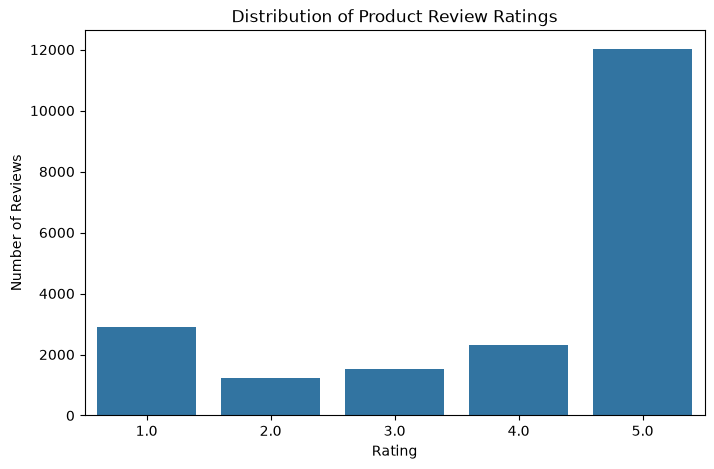

In [5]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="rating",
    order=sorted(df["rating"].dropna().unique())
)

plt.title("Distribution of Product Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

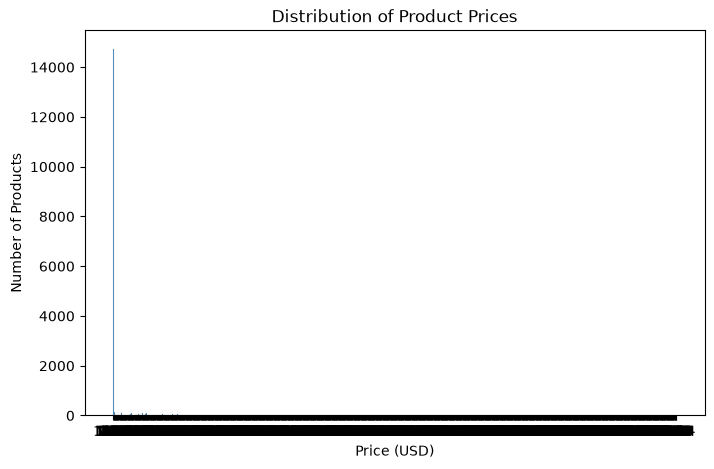

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["price"].dropna(),
    bins=30
)

plt.title("Distribution of Product Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Products")
plt.show()

verified_purchase
True     18157
False     1843
Name: count, dtype: int64


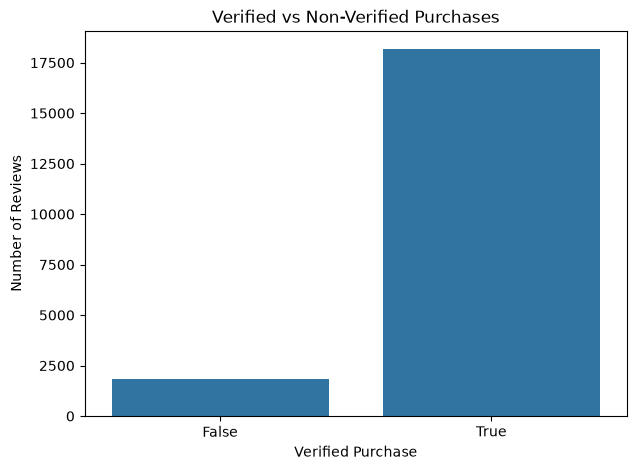

In [7]:
verified_counts = df["verified_purchase"].value_counts(dropna=False)

print(verified_counts)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="verified_purchase"
)

plt.title("Verified vs Non-Verified Purchases")
plt.xlabel("Verified Purchase")
plt.ylabel("Number of Reviews")
plt.show()

Average review length: 172.89
Minimum review length: 0
Maximum review length: 5666


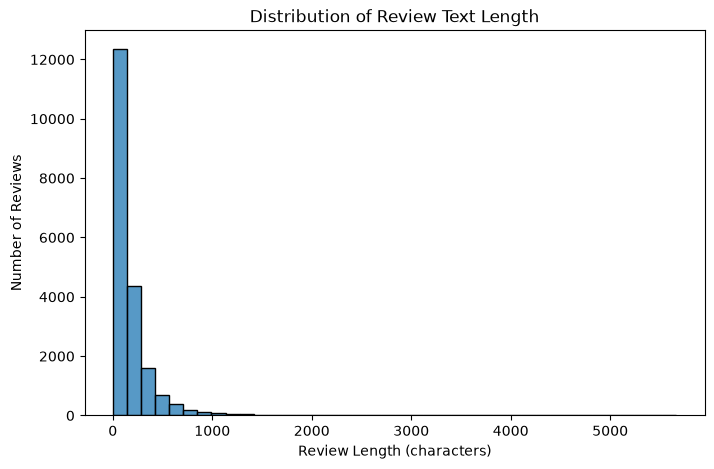

In [9]:
df["review_length"] = df["text"].fillna("").str.len()

print("Average review length:", round(df["review_length"].mean(), 2))
print("Minimum review length:", df["review_length"].min())
print("Maximum review length:", df["review_length"].max())

plt.figure(figsize=(8, 5))

sns.histplot(
    df["review_length"],
    bins=40
)

plt.title("Distribution of Review Text Length")
plt.xlabel("Review Length (characters)")
plt.ylabel("Number of Reviews")
plt.show()

Number of unique products: 12923
Average reviews per product: 1.55
Maximum reviews for one product: 62


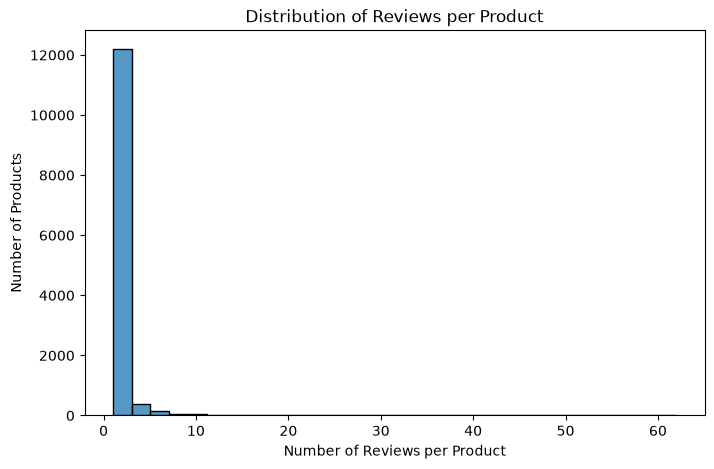

In [10]:
reviews_per_product = df.groupby("parent_asin").size()

print("Number of unique products:", reviews_per_product.shape[0])
print("Average reviews per product:", round(reviews_per_product.mean(), 2))
print("Maximum reviews for one product:", reviews_per_product.max())

plt.figure(figsize=(8, 5))

sns.histplot(
    reviews_per_product,
    bins=30
)

plt.title("Distribution of Reviews per Product")
plt.xlabel("Number of Reviews per Product")
plt.ylabel("Number of Products")
plt.show()

verified_purchase,False,True
rating,,
1.0,217,2696
2.0,101,1133
3.0,142,1389
4.0,324,1972
5.0,1059,10967


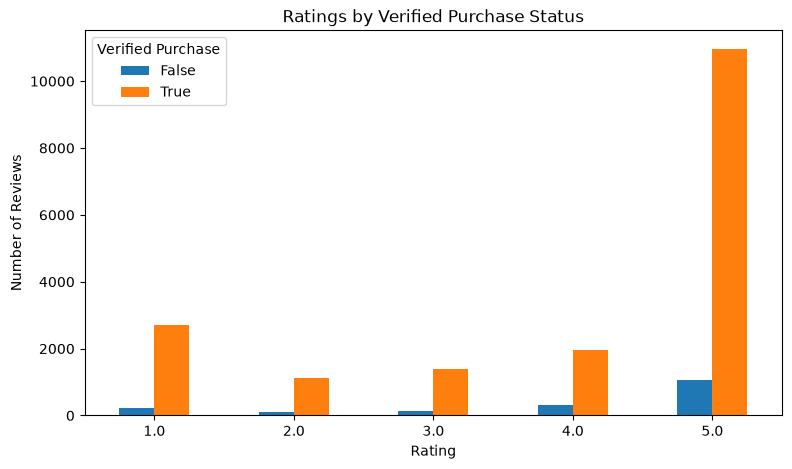

In [11]:
rating_verified = pd.crosstab(
    df["rating"],
    df["verified_purchase"]
)

display(rating_verified)

rating_verified.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Ratings by Verified Purchase Status")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Verified Purchase")
plt.show()

Missing values (%):


store    7.145
dtype: float64

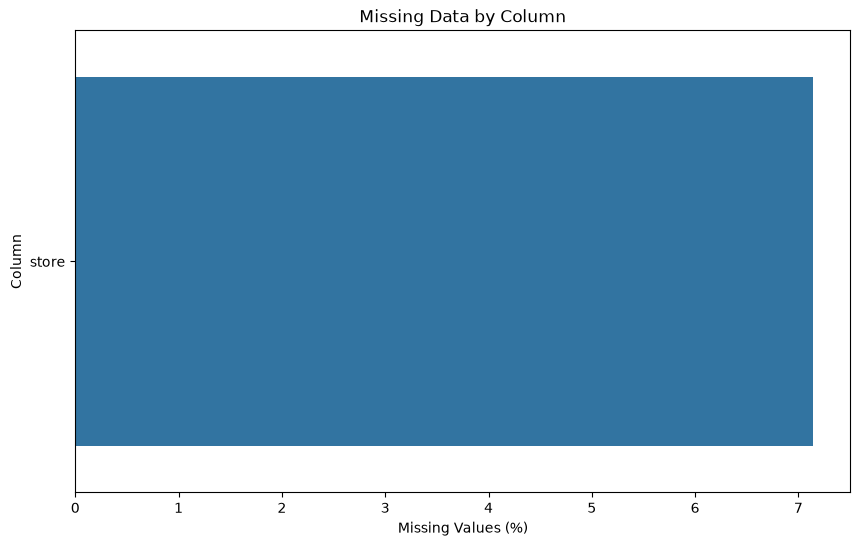

In [12]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent = missing_percent[missing_percent > 0]

print("Missing values (%):")
display(missing_percent)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index
)

plt.title("Missing Data by Column")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.show()